In [1]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from pychromatic import Multiplot

In [2]:
# ── Load CSV results ──────────────────────────────────────────────────────────
models = [
    ("ACE-Bi",        "eval_results_ACE.csv"),
    ("GRACE-2L-Bi",   "eval_results_GRACE_UPF.csv"),
    ("GRACE-2L-OMAT", "eval_results_GRACE_2L.csv"),
]

dfs = {}
for label, fname in models:
    dfs[label] = pd.read_csv(fname, index_col=0)

print("Columns:", list(dfs["ACE-Bi"].columns))
print("Rows per model:", {k: len(v) for k, v in dfs.items()})

Columns: ['n_atoms', 'energy', 'energy_corrected', 'dft_energy_per_atom', 'pred_energy', 'pred_energy_per_atom']
Rows per model: {'ACE-Bi': 3993, 'GRACE-2L-Bi': 3993, 'GRACE-2L-OMAT': 3993}


<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2698080/468662437.py:47: SyntaxWarning: invalid escape sequence '\m'
  mlt[0,0].set_ylabel("$E_\mathrm{DFT}$ (eV/atom)")
/tmp/ipykernel_2698080/468662437.py:48: SyntaxWa

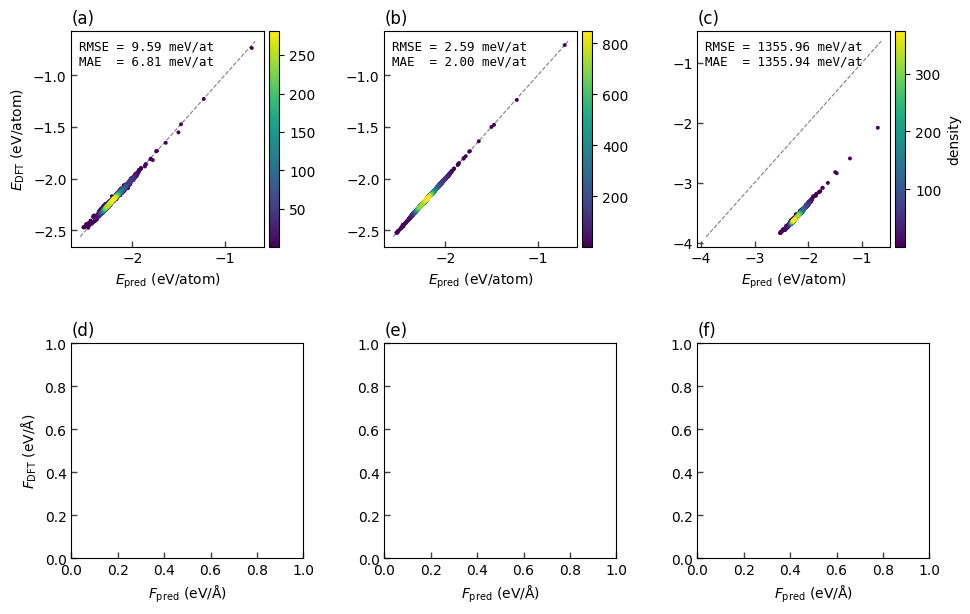

In [13]:
def density_scatter(ax, x, y, s=8, cmap="viridis", rasterized=True, **kw):
    """Scatter with points coloured by local Gaussian-KDE density."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    z = gaussian_kde(np.vstack([x, y]))(np.vstack([x, y]))
    idx = z.argsort()
    sc = ax.scatter(x[idx], y[idx], c=z[idx], s=s, cmap=cmap,
                    rasterized=rasterized, linewidths=0, **kw)
    return sc, x, y


def add_diagonal(ax, x, y, color="k", lw=0.8, ls="--", alpha=0.5):
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    pad = (hi - lo) * 0.02
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color=color, lw=lw, ls=ls, alpha=alpha, zorder=0)


def annotate_rmse(ax, x, y, unit="meV/atom", scale=1000):
    rmse = np.sqrt(np.mean((x - y) ** 2)) * scale
    mae  = np.mean(np.abs(x - y)) * scale
    ax.text(0.04, 0.96,
            f"RMSE = {rmse:.2f} {unit}\nMAE  = {mae:.2f} {unit}",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=9, family="monospace")


# ── Build 2 × 3 Multiplot ────────────────────────────────────────────────────
mlt = Multiplot(rows=2, columns=3, width=800, hspace=0.45, wspace=0.35)

for col, (label, _) in enumerate(models):
    df = dfs[label]

    # ── Row 0 : Energy parity ──────────────────────────────────────────────
    ax_e = mlt[0, col]
    x_e = df["dft_energy_per_atom"].values
    y_e = df["pred_energy_per_atom"].values
    sc, x_e, y_e = density_scatter(ax_e, x_e, y_e)
    add_diagonal(ax_e, x_e, y_e)
    annotate_rmse(ax_e, x_e, y_e, unit="meV/at", scale=1000)
    cb_label = "density" if col == 2 else ""
    plt.colorbar(sc, ax=ax_e, label=cb_label, pad=0.02)


mlt[0,0].set_ylabel("$E_\mathrm{DFT}$ (eV/atom)")
mlt[0,0].set_xlabel("$E_\mathrm{pred}$ (eV/atom)")
mlt[0,1].set_xlabel("$E_\mathrm{pred}$ (eV/atom)")
mlt[0,2].set_xlabel("$E_\mathrm{pred}$ (eV/atom)")
mlt[0,0].set_title('(a)', loc='left', fontsize=12)
mlt[0,1].set_title('(b)', loc='left', fontsize=12)
mlt[0,2].set_title('(c)', loc='left', fontsize=12)
    # ── Row 1 : Force parity ───────────────────────────────────────────────
    # add later

mlt[1,0].set_ylabel("$F_\mathrm{DFT}$ (eV/Å)")
mlt[1,0].set_xlabel("$F_\mathrm{pred}$ (eV/Å)")
mlt[1,1].set_xlabel("$F_\mathrm{pred}$ (eV/Å)")
mlt[1,2].set_xlabel("$F_\mathrm{pred}$ (eV/Å)")
mlt[1,0].set_title('(d)', loc='left', fontsize=12)
mlt[1,1].set_title('(e)', loc='left', fontsize=12)
mlt[1,2].set_title('(f)', loc='left', fontsize=12)
plt.savefig("parity_plots.png", dpi=300, bbox_inches="tight")
plt.show()